# Book Store!

Book recommandation system

### Part1 : reading data

imports

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import csv
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import TruncatedSVD

Reading Data

In [125]:
# this line would load the dataset, without the lines with errors
# df = pd.read_csv('Book_Ratings.csv', error_bad_lines=False, warn_bad_lines=True, sep=';')
df = pd.read_csv('Book_Ratings.csv', sep=';')
df.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


### Part1 : Basic analysis

Number of users </br>
Number of books </br>
Distribution of points </br>

In [126]:
# number of users
num_unique_users = df['User-ID'].nunique()
print(f"Number of unique users: {num_unique_users}")

# number of books
num_unique_books = df['ISBN'].nunique()
print(f"Number of unique books: {num_unique_books}")

Number of unique users: 105283
Number of unique books: 340556


### Contribution between books and rates

Calculation of average and number of marks for each book + saving in a scv

In [127]:
# Calculate the count and average rating for each book
book_ratings_summary = df.groupby('ISBN')['Book-Rating'].agg(['count', 'mean']).reset_index()

# Rename columns for better clarity
book_ratings_summary.columns = ['ISBN', 'Rating_Count', 'Average_Rating']

# Save results to a new CSV file
book_ratings_summary.to_csv('Q3_Book_Ratings_Summary.csv', index=False)

# Display the result
display(book_ratings_summary.head())

,ISBN,Rating_Count,Average_Rating
0,0330299891,2,3.0
1,0375404120,2,1.5
2,0586045007,1,0.0
3,9022906116,2,3.5
4,9032803328,1,0.0


In [128]:
# Chart settings
plt.figure(figsize=(12, 6))

# Draw a scatter plot with point size proportional to the rating count
sns.scatterplot(
    data=book_ratings_summary,
    x='Average_Rating', 
    y='Rating_Count', 
    size='Rating_Count', 
    sizes=(20, 200), # Range of point sizes
    alpha=0.6,
    legend=False
)

# Set title and labels
plt.title('Book Ratings Distribution: Average Rating vs. Rating Count')
plt.xlabel('Average Rating')
plt.ylabel('Rating Count (Density)')
plt.show()


### Contribution between users and books

Maximum number of ratings given by a single user: 13602
Average number of ratings per user: 10.920851419507423


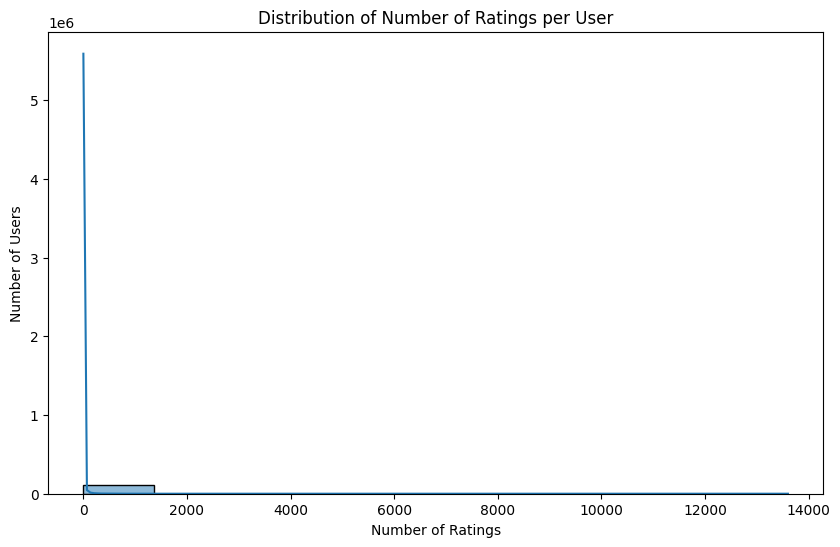

In [ ]:
# Count the number of ratings for each user
user_counts = df['User-ID'].value_counts()

# Find the maximum number of ratings by a single user
max_ratings = user_counts.max()
print("Maximum number of ratings given by a single user:", max_ratings)

# Calculate the average number of ratings per user
average_ratings = user_counts.mean()
print("Average number of ratings per user:", average_ratings)

# Plot the distribution of the number of ratings per user
plt.figure(figsize=(10, 6))
sns.histplot(user_counts, bins=10, kde=True)
plt.title('Distribution of Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.show()


### Filterring unactive users

In [ ]:
# unique users till now = 105283

# Filter users who have rated at least 10 times (active users)
active_users = user_counts[user_counts >= 10].index
df_active = df[df['User-ID'].isin(active_users)].copy()

# Get the number of active users
num_active_users = active_users.shape[0]
print("Number of users with at least 10 ratings:", num_active_users)


Number of users with at least 10 ratings: 13097


### creating sparse matrix

In [ ]:
# Map User-ID and ISBN to integer indices for sparse matrix
user_mapping = {user_id: idx for idx, user_id in enumerate(df_active['User-ID'].unique())}

book_mapping = {isbn: idx for idx, isbn in enumerate(df_active['ISBN'].unique())}

# Add indices to DataFrame
df_active['User_Index'] = df_active['User-ID'].map(user_mapping)
df_active['Book_Index'] = df_active['ISBN'].map(book_mapping)

# Create the sparse matrix (rows = users, columns = books, values = ratings)
sparse_matrix = csr_matrix((df_active['Book-Rating'], (df_active['User_Index'], df_active['Book_Index'])), 
                           shape=(len(user_mapping), len(book_mapping)))


Applying Pearson

In [ ]:
# Create a Truncated SVD model and reduce dimensions to 100

n_components=100

svd = TruncatedSVD(n_components)  # Number of reduced dimensions
reduced_matrix = svd.fit_transform(sparse_matrix)

In [ ]:
# Now you can use reduced_matrix as input for the KNN model
knn_model = NearestNeighbors(metric='correlation', algorithm='brute', n_neighbors=5, n_jobs=-1)
knn_model.fit(reduced_matrix)

NearestNeighbors(algorithm='brute', metric='correlation', n_jobs=-1)

In [ ]:
def recommend_books_optimized(sparse_matrix, user_vector, neighbors, top_n=5):
    # Identify books the user has not rated using the user_vector
    user_ratings_original = user_vector.flatten()
    unrated_books = np.where(user_ratings_original == 0)[0]

    # Extract neighbors' indices and similarities separately
    neighbor_indices = np.array([int(n[0]) for n in neighbors])
    similarities = np.array([n[1] for n in neighbors])

    # Calculate predicted ratings for unrated books in a vectorized way
    book_scores = {}
    for book_index in unrated_books:
        # Extract ratings of neighbors for this specific book in sparse_matrix
        neighbor_ratings = sparse_matrix[neighbor_indices, book_index].toarray().flatten()

        # Calculate weighted sum and similarity sum only where neighbor_rating > 0
        valid_ratings_mask = neighbor_ratings > 0
        weighted_sum = np.dot(similarities[valid_ratings_mask], neighbor_ratings[valid_ratings_mask])
        similarity_sum = np.sum(similarities[valid_ratings_mask])

        # Avoid division by zero
        if similarity_sum > 0:
            predicted_rating = weighted_sum / similarity_sum
            book_scores[book_index] = predicted_rating

    # Sort books by predicted rating and return top recommendations
    recommended_books = sorted(book_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return recommended_books


In [ ]:
def find_nearest_neighbors(knn_model, user_vector, n_neighbors=5):

    # Find the nearest neighbors for the provided user vector
    distances, indices = knn_model.kneighbors(user_vector, n_neighbors=n_neighbors)

    # Display the results
    neighbors = []
    for i, (distance, index) in enumerate(zip(distances.flatten(), indices.flatten())):
        neighbors.append((index, distance))
        print(f"Neighbor {i+1}: User Index = {index}, Pearson Distance = {distance}")
    
    return neighbors

In [ ]:
def find_nearest_neighbors_advanced(knn_model, user_vector, n_neighbors=5, existing_user=False):
    """
    Finds the nearest neighbors for a given user vector, with an option to exclude
    neighbors with distance below a threshold if the user already exists in the system.

    Parameters:
        knn_model (NearestNeighbors): Trained KNN model.
        user_vector (csr_matrix): Sparse matrix row representing the user.
        n_neighbors (int): Number of nearest neighbors to retrieve.
        existing_user (bool): Flag indicating if the user is already in the system.

    Returns:
        List of tuples containing neighbor index and distance.
    """
    # Request more neighbors to account for potential filtering
    extra_neighbors = n_neighbors + 1  # Request additional neighbors to ensure we get at least `n_neighbors`
    distances, indices = knn_model.kneighbors(user_vector, n_neighbors=extra_neighbors)
    
    neighbors = []
    for i, (distance, index) in enumerate(zip(distances.flatten(), indices.flatten())):
        # Convert distance to similarity (if needed)
        # similarity = 1 - distance  # Uncomment if you want to work with similarity

        # Apply condition to exclude neighbors with distance >= 0.9999 if existing_user is True
        if existing_user and distance <= 0.001:
            continue  # Skip this neighbor

        neighbors.append((index, distance))

        # Stop when we have gathered the required number of neighbors
        if len(neighbors) == n_neighbors:
            break

    # Display selected neighbors with their distances
    for i, (index, distance) in enumerate(neighbors, start=1):
        similarity = 1 - distance
        print(f"Neighbor {i}: User Index = {index}, Similarity = {similarity:.4f}")

        # print(f"Neighbor {i}: User Index = {index}, Pearson Distance = {distance:.4f}")
    
    return neighbors


In [ ]:
def recommend_books_squared(sparse_matrix, user_vector, neighbors, top_n=5):
    # Identify books the user has not rated using the user_vector
    user_ratings_original = user_vector.flatten()
    unrated_books = np.where(user_ratings_original == 0)[0]

    # Extract neighbors' indices and similarities separately
    neighbor_indices = np.array([int(n[0]) for n in neighbors])
    similarities = np.array([n[1] for n in neighbors])

    # Apply scaling to similarities (e.g., square the similarities)
    scaled_similarities = similarities ** 2

    # Calculate predicted ratings for unrated books
    book_scores = {}
    for book_index in unrated_books:
        # Extract ratings of neighbors for this specific book in sparse_matrix
        neighbor_ratings = sparse_matrix[neighbor_indices, book_index].toarray().flatten()

        # Calculate the average rating for each neighbor
        neighbor_averages = sparse_matrix[neighbor_indices].mean(axis=1).A1

        # Adjust ratings by subtracting the average rating of each neighbor
        adjusted_ratings = neighbor_ratings - neighbor_averages

        # Calculate weighted sum and similarity sum only where neighbor_rating > 0
        valid_ratings_mask = neighbor_ratings > 0
        weighted_sum = np.dot(scaled_similarities[valid_ratings_mask], adjusted_ratings[valid_ratings_mask])
        similarity_sum = np.sum(scaled_similarities[valid_ratings_mask])

        # Avoid division by zero
        if similarity_sum > 0:
            predicted_rating = weighted_sum / similarity_sum + user_vector.mean()
            book_scores[book_index] = predicted_rating

    # Sort books by predicted rating and return top recommendations
    recommended_books = sorted(book_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return recommended_books


In [ ]:
def recommend_books_exponential(sparse_matrix, user_vector, neighbors, top_n=5, scaling_factor=-5):
    # Identify books the user has not rated using the user_vector
    user_ratings_original = user_vector.flatten()
    unrated_books = np.where(user_ratings_original == 0)[0]

    # Extract neighbors' indices and similarities separately
    neighbor_indices = np.array([int(n[0]) for n in neighbors])
    similarities = np.array([n[1] for n in neighbors])

    # Apply exponential scaling to similarities
    scaled_similarities = np.exp(scaling_factor * (1 - similarities))

    # Calculate predicted ratings for unrated books
    book_scores = {}
    for book_index in unrated_books:
        # Extract ratings of neighbors for this specific book in sparse_matrix
        neighbor_ratings = sparse_matrix[neighbor_indices, book_index].toarray().flatten()

        # Calculate the average rating for each neighbor
        neighbor_averages = sparse_matrix[neighbor_indices].mean(axis=1).A1

        # Adjust ratings by subtracting the average rating of each neighbor
        adjusted_ratings = neighbor_ratings - neighbor_averages

        # Calculate weighted sum and similarity sum only where neighbor_rating > 0
        valid_ratings_mask = neighbor_ratings > 0
        weighted_sum = np.dot(scaled_similarities[valid_ratings_mask], adjusted_ratings[valid_ratings_mask])
        similarity_sum = np.sum(scaled_similarities[valid_ratings_mask])

        # Avoid division by zero
        if similarity_sum > 0:
            predicted_rating = weighted_sum / similarity_sum + user_vector.mean()
            book_scores[book_index] = predicted_rating

    # Sort books by predicted rating and return top recommendations
    recommended_books = sorted(book_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return recommended_books


In [ ]:
def recommend_books_filtered(sparse_matrix, user_vector, neighbors, top_n=5, scaling_factor=-5):
    # Identify books the user has not rated using the user_vector
    user_ratings_original = user_vector.flatten()
    unrated_books = np.where(user_ratings_original == 0)[0]

    # Extract neighbors' indices and similarities separately
    neighbor_indices = np.array([int(n[0]) for n in neighbors])
    similarities = np.array([n[1] for n in neighbors])

    # Apply exponential scaling to similarities to reduce effect of low similarities
    scaled_similarities = np.exp(scaling_factor * (1 - similarities))

    # Calculate predicted ratings for unrated books
    book_scores = {}
    for book_index in unrated_books:
        # Extract ratings of neighbors for this specific book in sparse_matrix
        neighbor_ratings = sparse_matrix[neighbor_indices, book_index].toarray().flatten()

        # Filter out neighbors with zero ratings for this specific book
        valid_ratings_mask = neighbor_ratings > 0
        if not np.any(valid_ratings_mask):  # If no valid ratings, skip this book
            continue

        # Calculate weighted sum and similarity sum for valid ratings only
        weighted_sum = np.dot(scaled_similarities[valid_ratings_mask], neighbor_ratings[valid_ratings_mask])
        similarity_sum = np.sum(scaled_similarities[valid_ratings_mask])

        # Avoid division by zero
        if similarity_sum > 0:
            predicted_rating = weighted_sum / similarity_sum
            book_scores[book_index] = predicted_rating

    # Sort books by predicted rating and return top recommendations
    recommended_books = sorted(book_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return recommended_books


In [ ]:
def recommend_books_with_mask(sparse_matrix, user_vector, neighbors, top_n=5, scaling_factor=-5):
    # Create a mask matrix indicating the presence of actual ratings (1) or missing values (0)
    mask_matrix = sparse_matrix.copy()
    mask_matrix.data = np.ones_like(mask_matrix.data)  # Replace all non-zero values with 1 to indicate presence

    # Identify books the user has not rated using the user_vector
    user_ratings_original = user_vector.flatten()
    unrated_books = np.where(user_ratings_original == 0)[0]  # Assuming 0 means unrated in user_vector

    # Extract neighbors' indices and similarities separately
    neighbor_indices = np.array([int(n[0]) for n in neighbors])
    similarities = np.array([n[1] for n in neighbors])

    # Apply exponential scaling to similarities to reduce effect of low similarities
    scaled_similarities = np.exp(scaling_factor * (1 - similarities))

    # Calculate predicted ratings for unrated books
    book_scores = {}
    for book_index in unrated_books:
        # Extract ratings and mask for neighbors for this specific book in sparse_matrix and mask_matrix
        neighbor_ratings = sparse_matrix[neighbor_indices, book_index].toarray().flatten()
        neighbor_mask = mask_matrix[neighbor_indices, book_index].toarray().flatten()

        # Filter out neighbors with missing ratings based on mask
        valid_ratings_mask = neighbor_mask > 0  # Only keep entries where mask is 1 (i.e., actual ratings exist)

        if not np.any(valid_ratings_mask):  # If no valid ratings, skip this book
            continue

        # Calculate weighted sum and similarity sum for valid ratings only
        weighted_sum = np.dot(scaled_similarities[valid_ratings_mask], neighbor_ratings[valid_ratings_mask])
        similarity_sum = np.sum(scaled_similarities[valid_ratings_mask])

        # Avoid division by zero
        if similarity_sum > 0:
            predicted_rating = weighted_sum / similarity_sum
            book_scores[book_index] = predicted_rating

    # Sort books by predicted rating and return top recommendations
    recommended_books = sorted(book_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return recommended_books


In [ ]:
def recommend_books_ignore_zeros(sparse_matrix, user_vector, neighbors, top_n=5, scaling_factor=-5):
    # Identify books the user has not rated using the user_vector
    user_ratings_original = user_vector.flatten()
    unrated_books = np.where(user_ratings_original == 0)[0]  # فرض می‌کنیم 0 یعنی نمره‌گذاری نشده است

    # Extract neighbors' indices and similarities separately
    neighbor_indices = np.array([int(n[0]) for n in neighbors])
    similarities = np.array([n[1] for n in neighbors])

    # Apply exponential scaling to similarities to reduce effect of low similarities
    scaled_similarities = np.exp(scaling_factor * (1 - similarities))

    # Calculate predicted ratings for unrated books
    book_scores = {}
    for book_index in unrated_books:
        # Extract ratings of neighbors for this specific book in sparse_matrix
        neighbor_ratings = sparse_matrix[neighbor_indices, book_index].toarray().flatten()

        # Filter out neighbors with zero ratings
        valid_ratings_mask = neighbor_ratings > 0  # فقط نمرات مثبت را در نظر بگیریم

        # Skip this book if no valid ratings
        if not np.any(valid_ratings_mask):
            continue

        # Calculate weighted sum and similarity sum for valid ratings only
        weighted_sum = np.dot(scaled_similarities[valid_ratings_mask], neighbor_ratings[valid_ratings_mask])
        similarity_sum = np.sum(scaled_similarities[valid_ratings_mask])

        # Avoid division by zero
        if similarity_sum > 0:
            predicted_rating = weighted_sum / similarity_sum
            book_scores[book_index] = predicted_rating

    # Sort books by predicted rating and return top recommendations
    recommended_books = sorted(book_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return recommended_books

In [ ]:
from collections import defaultdict

# Function to recommend books based on nearest neighbors' ratings with frequency consideration
def recommend_books_with_frequency(sparse_matrix, user_vector, neighbors, top_n=5):
    """
    Recommend books based on both the predicted rating and frequency of occurrence among neighbors.
    
    Parameters:
        sparse_matrix (csr_matrix): The main sparse matrix containing all user-book ratings.
        user_vector (np.ndarray): Sparse matrix row representing the user.
        neighbors (list of tuples): List of tuples, where each tuple contains (neighbor_index, similarity).
        top_n (int): Number of top recommended books to return.

    Returns:
        List of tuples containing book index and predicted rating.
    """
    # Identify books the user has not rated
    user_ratings = user_vector.flatten()  # No need for toarray() if user_vector is already a NumPy array
    unrated_books = np.where(user_ratings == 0)[0]

    # Create a dictionary to hold the total weighted scores and frequency counts
    book_scores = defaultdict(float)
    book_frequencies = defaultdict(int)
    
    # Separate indices and similarities of neighbors
    neighbor_indices = np.array([int(n[0]) for n in neighbors])
    similarities = np.array([n[1] for n in neighbors])

    # Calculate scores and frequency counts
    for book_index in unrated_books:
        neighbor_ratings = sparse_matrix[neighbor_indices, book_index].toarray().flatten()
        
        # Only consider neighbors with non-zero ratings
        valid_ratings_mask = neighbor_ratings > 0
        if np.any(valid_ratings_mask):
            # Weighted sum of ratings by similarity
            weighted_sum = np.dot(similarities[valid_ratings_mask], neighbor_ratings[valid_ratings_mask])
            similarity_sum = np.sum(similarities[valid_ratings_mask])

            if similarity_sum > 0:
                predicted_rating = weighted_sum / similarity_sum
                book_scores[book_index] += predicted_rating
                book_frequencies[book_index] += np.sum(valid_ratings_mask)  # Count the number of neighbors who rated this book

    # Combine scores and frequencies to prioritize frequent, highly-rated books
    combined_scores = {book: (book_scores[book], book_frequencies[book]) for book in book_scores}

    # Sort by frequency first, then by predicted rating
    recommended_books = sorted(combined_scores.items(), key=lambda x: (x[1][1], x[1][0]), reverse=True)[:top_n]

    return recommended_books


In [ ]:
def display_recommended_books(recommended_books, book_mapping):

    # Reverse book_mapping to map indices back to ISBNs
    index_to_isbn = {index: isbn for isbn, index in book_mapping.items()}
    
    print("Recommended Books:")
    for book_index, predicted_rating in recommended_books:
        # Convert index to ISBN
        isbn = index_to_isbn.get(book_index, "Unknown ISBN")
                
        # print(f"ISBN: {isbn}, Predicted Rating: {predicted_rating}")
        print(f"ISBN: {isbn}, Predicted Rating: {predicted_rating:.4f}")

In [ ]:
def display_recommended_books_frequency(recommended_books, book_mapping):
    # Map book indices to ISBN
    index_to_isbn = {index: isbn for isbn, index in book_mapping.items()}
    
    if not recommended_books:
        print("No recommended books available.")
        return
    
    print("Recommended Books:")
    for book_index, (predicted_rating, frequency) in recommended_books:
        # Retrieve ISBN for the book index or show "Unknown ISBN" if not found
        isbn = index_to_isbn.get(book_index, "Unknown ISBN")
        
        # Optionally limit predicted_rating to a certain range (e.g., 1 to 10)
        predicted_rating = max(1, min(10, predicted_rating))
        
        # Display the book with its ISBN, predicted rating, and frequency
        print(f"ISBN: {isbn}, Predicted Rating: {predicted_rating:.4f}, Frequency: {frequency}")


In [ ]:
def display_recommended_books_frequency(recommended_books, book_mapping):
    # Map book indices to ISBN
    index_to_isbn = {index: isbn for isbn, index in book_mapping.items()}
    
    if not recommended_books:
        print("No recommended books available.")
        return
    
    print("Recommended Books:")
    for book_index, (predicted_rating, frequency) in recommended_books:
        # Retrieve ISBN for the book index or show "Unknown ISBN" if not found
        isbn = index_to_isbn.get(book_index, "Unknown ISBN")
        
        # Optionally limit predicted_rating to a certain range (e.g., 1 to 10)
        predicted_rating = max(1, min(10, predicted_rating))
        
        # Display the book with its ISBN, predicted rating, and frequency
        print(f"ISBN: {isbn}, Predicted Rating: {predicted_rating:.4f}, Frequency: {frequency}")


In [ ]:
def print_neighbor_ratings(sparse_matrix, user_vector, neighbors):
    # Identify books the user has not rated using the user_vector
    user_ratings_original = user_vector.flatten()
    unrated_books = np.where(user_ratings_original == 0)[0]

    # Extract neighbors' indices
    neighbor_indices = np.array([int(n[0]) for n in neighbors])

    print("Unrated books by the target user and ratings from neighbors:\n")
    
    # Iterate over each unrated book
    for book_index in unrated_books:
        print(f"Book Index: {book_index}")

        # Get the ratings from neighbors for this specific book
        neighbor_ratings = sparse_matrix[neighbor_indices, book_index].toarray().flatten()
        
        # Print ratings given by each neighbor for this book
        for i, neighbor_index in enumerate(neighbor_indices):
            print(f"  Neighbor {i+1} (User Index: {neighbor_index}) - Rating: {neighbor_ratings[i]}")
        
        print("-" * 30)  # Separator for each book

In [ ]:
def save_neighbor_ratings_to_file(sparse_matrix, user_vector, neighbors, file_path="neighbor_ratings.txt"):
    # Identify books the user has not rated using the user_vector
    user_ratings_original = user_vector.flatten()
    unrated_books = np.where(user_ratings_original == 0)[0]

    # Extract neighbors' indices
    neighbor_indices = np.array([int(n[0]) for n in neighbors])

    with open(file_path, "w") as f:
        f.write("Unrated books by the target user and ratings from neighbors:\n\n")
        
        # Iterate over each unrated book
        for book_index in unrated_books:
            f.write(f"Book Index: {book_index}\n")

            # Get the ratings from neighbors for this specific book
            neighbor_ratings = sparse_matrix[neighbor_indices, book_index].toarray().flatten()
            
            # Write ratings given by each neighbor for this book
            for i, neighbor_index in enumerate(neighbor_indices):
                f.write(f"  Neighbor {i+1} (User Index: {neighbor_index}) - Rating: {neighbor_ratings[i]}\n")
            
            f.write("-" * 30 + "\n")  # Separator for each book


In [ ]:
def save_nonzero_ratings_per_neighbor(sparse_matrix, neighbors, file_path="neighbor_nonzero_ratings_with_scores.txt"):
    """
    Saves the list of books with non-zero ratings and their scores for each neighbor to a text file.
    
    Parameters:
        sparse_matrix (csr_matrix): The main sparse matrix containing all user-book ratings.
        neighbors (list of tuples): List of tuples, where each tuple contains (neighbor_index, similarity).
        file_path (str): Path to save the output file.
    """
    with open(file_path, "w") as f:
        f.write("Books with non-zero ratings and their scores by each neighbor:\n\n")
        
        for i, (neighbor_index, similarity) in enumerate(neighbors, start=1):
            # Extract the ratings of the current neighbor (user)
            neighbor_ratings = sparse_matrix[neighbor_index].toarray().flatten()
            
            # Find indices of books with non-zero ratings and their corresponding scores
            nonzero_book_indices = np.where(neighbor_ratings > 0)[0]
            nonzero_book_ratings = neighbor_ratings[nonzero_book_indices]

            # Write neighbor information and ratings to the file
            f.write(f"Neighbor {i} (User Index: {neighbor_index}, Similarity: {similarity}):\n")
            f.write("Books with non-zero ratings and their scores:\n")
            
            for book_index, rating in zip(nonzero_book_indices, nonzero_book_ratings):
                f.write(f"  Book Index: {book_index}, Rating: {rating}\n")

            f.write("-" * 50 + "\n")

            # Optional: Print details in console for debugging
            print(f"Neighbor {i} (User Index: {neighbor_index}) has rated books and scores: {list(zip(nonzero_book_indices, nonzero_book_ratings))}")

    print(f"Results saved to {file_path}")


## Best Combination

In [ ]:
# Find nearest neighbors for an existing user

print("Pearson similarity!")

# Assume that the target user is the first user
user_index = 0  # Example: first user

# First, reduce the dimensionality of the user vector
user_vector = sparse_matrix[user_index].toarray().reshape(1, -1)
user_vector_reduced = svd.transform(user_vector)

# Find the nearest neighbors for the target user using the reduced vector
neighbors = find_nearest_neighbors_advanced(knn_model, user_vector_reduced, n_neighbors=5, existing_user=True)

print("neighbors: ", neighbors)

save_nonzero_ratings_per_neighbor(sparse_matrix, neighbors)

recommended_books = recommend_books_with_frequency(sparse_matrix, user_vector, neighbors, top_n = 5)

# print("recommended_books: ", recommended_books)

# Display the recommended books
display_recommended_books_frequency(recommended_books, book_mapping)


Pearson similarity!
Neighbor 1: User Index = 3714, Similarity = 0.7531
Neighbor 2: User Index = 1913, Similarity = 0.7497
Neighbor 3: User Index = 9877, Similarity = 0.7490
Neighbor 4: User Index = 12173, Similarity = 0.7482
Neighbor 5: User Index = 7706, Similarity = 0.7470
neighbors:  [(3714, 0.2469063952124556), (1913, 0.2502736679663742), (9877, 0.2510237331738202), (12173, 0.2518481523919395), (7706, 0.2530058319176587)]
Neighbor 1 (User Index: 3714) has rated books and scores: [(4701, 2), (43717, 5), (72188, 3), (131163, 6), (131164, 5)]
Neighbor 2 (User Index: 1913) has rated books and scores: [(44229, 6), (60160, 7), (88281, 6)]
Neighbor 3 (User Index: 9877) has rated books and scores: [(49871, 10), (217165, 8)]
Neighbor 4 (User Index: 12173) has rated books and scores: [(12232, 5)]
Neighbor 5 (User Index: 7706) has rated books and scores: [(2, 9), (377, 9), (458, 9), (573, 5), (574, 7), (578, 7), (586, 6), (834, 6), (986, 8), (1076, 10), (1119, 5), (1207, 9), (1208, 9), (1219,

In [ ]:
# Finding nearest neighbors for a random user

# Create a random user vector
num_books = sparse_matrix.shape[1]
# Generate random ratings between 0 and 5 for each book
random_user_ratings = np.random.randint(0, 6, size=num_books)
# Create a sparse matrix for the random user
random_user_sparse = csr_matrix(random_user_ratings)

# Reduce the dimensionality of the random user vector using SVD
random_user_vector_reduced = svd.transform(random_user_sparse)

# Find and print nearest neighbors for this user using the reduced random user vector
neighbors = find_nearest_neighbors_advanced(knn_model, random_user_vector_reduced, n_neighbors=5, existing_user=False)

print("neighbors: ", neighbors)

# Convert sparse vector to dense array and flatten
random_user_dense = random_user_sparse.toarray().flatten()

# Recommend books based on the random user's ratings
recommended_books = recommend_books_with_frequency(sparse_matrix, random_user_dense, neighbors, top_n=5)

# Display the recommended books
display_recommended_books_frequency(recommended_books, book_mapping)


Neighbor 1: User Index = 575, Similarity = 0.4849
Neighbor 2: User Index = 12245, Similarity = 0.4767
Neighbor 3: User Index = 7488, Similarity = 0.4732
Neighbor 4: User Index = 1347, Similarity = 0.4652
Neighbor 5: User Index = 3276, Similarity = 0.4512
neighbors:  [(575, 0.5151274542079627), (12245, 0.5232899040241228), (7488, 0.5267615737203046), (1347, 0.5347585523234883), (3276, 0.5487662266581057)]
Recommended Books:
ISBN: 0345452550, Predicted Rating: 8.9813, Frequency: 2
ISBN: 0671525751, Predicted Rating: 8.9813, Frequency: 2
ISBN: 0451403703, Predicted Rating: 7.9813, Frequency: 2
ISBN: 0439064864, Predicted Rating: 10.0000, Frequency: 1
ISBN: 0679745203, Predicted Rating: 10.0000, Frequency: 1


In [ ]:
# Find nearest neighbors for an existing user

# Assume that the target user is the first user
user_index = 0  # Example: first user

# First, reduce the dimensionality of the user vector
user_vector = sparse_matrix[user_index].toarray().reshape(1, -1)
user_vector_reduced = svd.transform(user_vector)

# Find the nearest neighbors for the target user using the reduced vector
neighbors = find_nearest_neighbors(knn_model, user_vector_reduced, n_neighbors=5)

# save_neighbor_ratings_to_file(sparse_matrix, user_vector, neighbors, "neighbor_rating_mask.txt")
# print_neighbor_ratings(sparse_matrix, user_vector, neighbors)

recommended_books = recommend_books_with_mask(sparse_matrix, user_vector, neighbors, top_n = 5, scaling_factor=-5)

print("recommended_books: ", recommended_books)

# Display the recommended books
display_recommended_books(recommended_books, book_mapping)


Neighbor 1: User Index = 0, Pearson Distance = 0.0
Neighbor 2: User Index = 3714, Pearson Distance = 0.2469063952124556
Neighbor 3: User Index = 1913, Pearson Distance = 0.2502736679663742
Neighbor 4: User Index = 9877, Pearson Distance = 0.2510237331738202
Neighbor 5: User Index = 12173, Pearson Distance = 0.2518481523919395
recommended_books:  [(49871, 10.0), (217165, 8.0), (60160, 7.0), (44229, 6.0), (88281, 6.0)]
Recommended Books:
ISBN: 0446677671, Predicted Rating: 10.0000
ISBN: 1888306149, Predicted Rating: 8.0000
ISBN: 0061095540, Predicted Rating: 7.0000
ISBN: 0446603686, Predicted Rating: 6.0000
ISBN: 0399512829, Predicted Rating: 6.0000


In [ ]:
# Find nearest neighbors for an existing user

# Assume that the target user is the first user
user_index = 0  # Example: first user

# First, reduce the dimensionality of the user vector
user_vector = sparse_matrix[user_index].toarray().reshape(1, -1)
user_vector_reduced = svd.transform(user_vector)

# Find the nearest neighbors for the target user using the reduced vector
neighbors = find_nearest_neighbors(knn_model, user_vector_reduced, n_neighbors=5)

save_neighbor_ratings_to_file(sparse_matrix, user_vector, neighbors, file_path="recommend_books_ignore_zeros_pearson.txt")

recommended_books = recommend_books_ignore_zeros(sparse_matrix, user_vector, neighbors, top_n = 5, scaling_factor=-5)

print("recommended_books: ", recommended_books)

# Display the recommended books
display_recommended_books(recommended_books, book_mapping)


Neighbor 1: User Index = 0, Pearson Distance = 0.0
Neighbor 2: User Index = 3714, Pearson Distance = 0.2469063952124556
Neighbor 3: User Index = 1913, Pearson Distance = 0.2502736679663742
Neighbor 4: User Index = 9877, Pearson Distance = 0.2510237331738202
Neighbor 5: User Index = 12173, Pearson Distance = 0.2518481523919395
recommended_books:  [(49871, 10.0), (217165, 8.0), (60160, 7.0), (44229, 6.0), (88281, 6.0)]
Recommended Books:
ISBN: 0446677671, Predicted Rating: 10.0000
ISBN: 1888306149, Predicted Rating: 8.0000
ISBN: 0061095540, Predicted Rating: 7.0000
ISBN: 0446603686, Predicted Rating: 6.0000
ISBN: 0399512829, Predicted Rating: 6.0000
